In [7]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
iris = load_iris()

In [16]:
X = iris.data
# X.columns = iris.feature_names
y = iris.target

In [19]:
X.shape

(150, 4)

<Axes: >

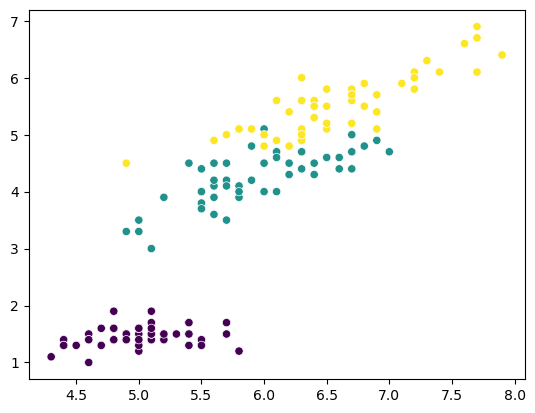

In [22]:
sns.scatterplot(x=X[:, 0], y=X[:, 2], c=y)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import os
os.environ["OMP_NUM_THREADS"] = "1"

In [40]:
#dimensionally reduction using PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [41]:

k=3
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)




<Axes: >

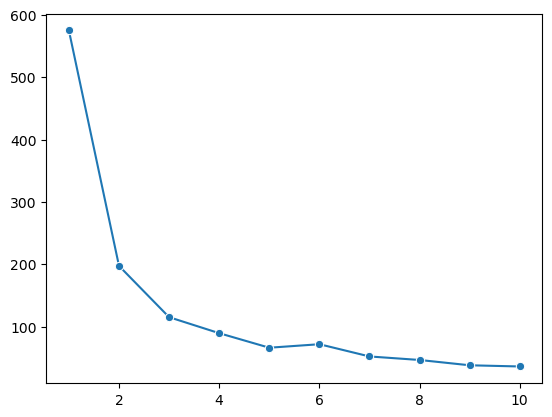

In [42]:
sns.lineplot(x=range(1, 11), y=wcss, marker='o')

<Axes: >

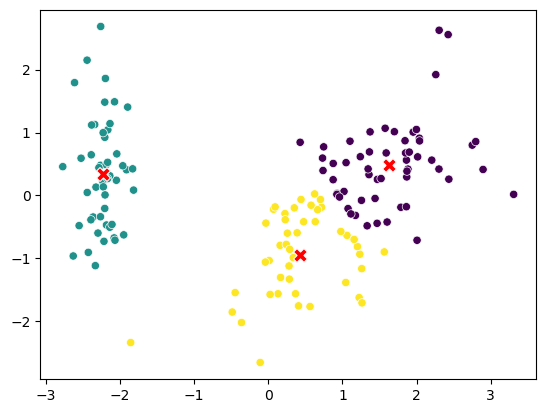

In [56]:
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker='X', c="red", s=100)